# Conversation Evaluation – Exploratory Data Analysis
A cleaned‑up, fully reproducible version of the original notebook. Paths remain unchanged; feel free to adjust configuration values where indicated.

## 1. Imports & Environment

In [9]:
import os, sys, ast, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)
warnings.filterwarnings("ignore")

# Walk up from CWD to find the self-contained experiment root, identified by its key files.
_HELPER_FILES = ['openai_key.txt', 'HF_key.txt']
_cur = os.path.abspath(os.getcwd())
_EXPERIMENT_ROOT = None
for _ in range(8):
    if all(os.path.exists(os.path.join(_cur, _hf)) for _hf in _HELPER_FILES):
        _EXPERIMENT_ROOT = _cur
        break
    _parent = os.path.dirname(_cur)
    if _parent == _cur:
        break
    _cur = _parent
if _EXPERIMENT_ROOT is None or os.path.basename(_EXPERIMENT_ROOT) != 'Exp1_ICLR2025':
    raise RuntimeError(f'Could not locate Exp1_ICLR2025 experiment root from {os.getcwd()!r}')
if _EXPERIMENT_ROOT not in sys.path:
    sys.path.insert(0, _EXPERIMENT_ROOT)

# Map legacy `LLM_DATA/...` path prefixes to the new experiment-rooted layout.
_PATH_REMAP = [
    ("LLM_DATA/Conversation_with_Eval/", "data/conversations_eval"),
    ("LLM_DATA/Conversation_Trees/",     "data/conversation_trees"),
]

def _resolve_data_path(p):
    for _old, _new in _PATH_REMAP:
        if p.startswith(_old):
            return os.path.join(_EXPERIMENT_ROOT, _new, p[len(_old):])
    return p

## 2. Helper Functions

In [10]:
def preprocess_conversation(conversation_pd, id=-1):
    conversation_list = conversation_pd["conversation"].tolist()
    session_endded_by = conversation_pd["session_endded_by"][0]
    session_endded_explanation = conversation_pd["session_endded_explanation"][0]

    processed_data = {
        "id": id,
        "conversation_length": len(conversation_list),
        "session_endded_by": session_endded_by,
        "session_endded_explanation": session_endded_explanation,
        "conversation": conversation_list
    }
    return processed_data


def load_conversations(data_path, start_idx=0, end_idx=96):
    """Load and preprocess conversation data from CSV files."""
    conversations = []
    for i in range(start_idx, end_idx):
        file_path = os.path.join(data_path, f"conversation_{i}.csv")
        # file_path = data_path + f"/conversation_{i}.csv"
        try:
            conversation_pd = pd.read_csv(file_path)
            conversation_dict = preprocess_conversation(conversation_pd, i)
            conversations.append(conversation_dict)
        except FileNotFoundError:
            print(f"Warning: {file_path} not found. Skipping.")
    return pd.DataFrame(conversations)

def preprocess_scores(scores_pd, id=-1):
    scores1 = scores_pd["scores1"].apply(ast.literal_eval)
    scores2 = scores_pd["scores2"].apply(ast.literal_eval)
    
    scores_dict = {
        "id": id,
        "scores1": scores1[0],
        "scores2": scores2[0],
        "scores1_avg": scores_pd["scores1_avg"][0],
        "scores2_avg": scores_pd["scores2_avg"][0],
        "scores_avg": scores_pd["scores_avg"][0],
        "results1": scores_pd["results1"][0],
        "results2": scores_pd["results2"][0],
    }
    return scores_dict

def load_scores(data_path, start_idx=0, end_idx=96):
    """Load and preprocess scores data from CSV files."""
    scores = []
    for i in range(start_idx, end_idx):
        file_path = os.path.join(data_path, f"scores_{i}.csv")
        # file_path = data_path + f"/scores_{i}.csv"
        try:
            score_pd = pd.read_csv(file_path)
            score_dict = preprocess_scores(score_pd, i)
            scores.append(score_dict)
        except FileNotFoundError:
            print(f"Warning: {file_path} not found. Skipping.")
    return pd.DataFrame(scores)

def load_data(data_paths):
    data_sets = []
    for data_path in data_paths:
        curr_conversations = load_conversations(data_path)
        curr_scores = load_scores(data_path)
        data_set = pd.merge(curr_conversations, curr_scores, on="id")
        data_sets.append(data_set)
    return data_sets

def combine_data(data_sets, model_names):
    combined_data = pd.concat(
        [data_set.assign(Model=model_name) for data_set, model_name in zip(data_sets, model_names)]
    )
    return combined_data

def print_conversation(conversation, max_width=80):
    for i, message in enumerate(conversation):
        role = "[THERAPIST]" if i % 2 == 0 else "[PATIENT]"
        print(f"{role}: \n{textwrap.fill(message, width=max_width)} \n")

## 3. Configuration – Paths & Model names

In [11]:
## ---------------------------------------------------------------------
## 3. Configuration – Data paths & options
## ---------------------------------------------------------------------
# The two blocks below come verbatim from the original notebook.
# Uncomment the one you want to use. Feel free to edit paths, but keep
# the list variable name **data_paths** unchanged.

# -------- New experiment data --------
########################## NEW EXPERIMENT DATA ###########################
########################## NEW EXPERIMENT DATA ###########################

data_paths = [
    ################# Base #################
    # "LLM_DATA/Conversation_with_Eval/Base/Instruct_TT0.7_TP0.7", # Base 50 Instruct
    # "LLM_DATA/Conversation_with_Eval/Base/Basic_50_TT0.9_TP0.7_TE0.2", # Base length 50
    "LLM_DATA/Conversation_with_Eval/Base/Basic_50_TT0.9_TP0.7_TE0.2_V2", # Base length 50 NEW



    ################# Look-Ahead=0, FullEval, Length=50 #################
    "LLM_DATA/Conversation_with_Eval/LookAhead_0/TTree1.4_TT0.9_TP0.7_TE0.2_V1",
    "LLM_DATA/Conversation_with_Eval/LookAhead_0/TTree1.4_TT0.9_TP0.7_TE0.2_V2",
    "LLM_DATA/Conversation_with_Eval/LookAhead_0/TTree1.4_TT0.9_TP0.7_TE0.2_V3",
    "LLM_DATA/Conversation_with_Eval/LookAhead_0/TTree1.4_TT0.9_TP0.7_TE0.2_V4",
    "LLM_DATA/Conversation_with_Eval/LookAhead_0/TTree1.4_TT0.9_TP0.7_TE0.2_V5",
    "LLM_DATA/Conversation_with_Eval/LookAhead_0/TTree1.4_TT0.9_TP0.7_TE0.2_V6",
    "LLM_DATA/Conversation_with_Eval/LookAhead_0/TTree1.4_TT0.9_TP0.7_TE0.2_V7",

    ################ Look-Ahead=5, FullEval, Length=50 #################
    "LLM_DATA/Conversation_with_Eval/LookAhead_5/TTree1.4_TT0.9_TP0.7_TE0.2_V1",
    "LLM_DATA/Conversation_with_Eval/LookAhead_5/TTree1.4_TT0.9_TP0.7_TE0.2_V2",
    "LLM_DATA/Conversation_with_Eval/LookAhead_5/TTree1.4_TT0.9_TP0.7_TE0.2_V3",
    "LLM_DATA/Conversation_with_Eval/LookAhead_5/TTree1.4_TT0.9_TP0.7_TE0.2_V4",
    "LLM_DATA/Conversation_with_Eval/LookAhead_5/TTree1.4_TT0.9_TP0.7_TE0.2_V5",
    "LLM_DATA/Conversation_with_Eval/LookAhead_5/TTree1.4_TT0.9_TP0.7_TE0.2_V6",
    "LLM_DATA/Conversation_with_Eval/LookAhead_5/TTree1.4_TT0.9_TP0.7_TE0.2_V7",

    # ################ Q2, Look-Ahead=5, FullEval, Length=50 #################
    # "LLM_DATA/Conversation_with_Eval/LookAhead_5/Q2_TTree1.4_TT0.9_TP0.7_TE0.2_V1",
    # "LLM_DATA/Conversation_with_Eval/LookAhead_5/Q2_TTree1.4_TT0.9_TP0.7_TE0.2_V2",
    # "LLM_DATA/Conversation_with_Eval/LookAhead_5/Q2_TTree1.4_TT0.9_TP0.7_TE0.2_V3",
    # "LLM_DATA/Conversation_with_Eval/LookAhead_5/Q2_TTree1.4_TT0.9_TP0.7_TE0.2_V4",

]

model_names = [
    ################# Base #################
    # "Base_In", # Base 50 Instruct
    "Base",
    ################# Look-Ahead=5, FullEval, Length=50 #################
    "L0_M1",
    "L0_M2",
    "L0_M3",
    "L0_M4",
    "L0_M5",
    "L0_M6",
    "L0_M7",
    ################# Look-Ahead=5, FullEval, Length=50 #################
    "L5_M1",
    "L5_M2",
    "L5_M3",
    "L5_M4",
    "L5_M5",
    "L5_M6",
    "L5_M7",
    # ################ Q2, Look-Ahead=5, FullEval, Length=50 #################
    # "Q2_M1",
    # "Q2_M2",
    # "Q2_M3",
    # "Q2_M4",

]

########################## NEW EXPERIMENT DATA ###########################
########################## NEW EXPERIMENT DATA ###########################



# -------- Best‑iteration subset --------
# To use this smaller benchmark list instead, comment‑out the block above
# and uncomment everything in the next block:
# ########################## NEW EXPERIMENT BEST ITERATION DATA ###########################
# ########################## NEW EXPERIMENT BEST ITERATION DATA ###########################
# 
# data_paths = [
#     ################# Base #################
#     # "LLM_DATA/Conversation_with_Eval/Base/Instruct_TT0.7_TP0.7", # Base 50 Instruct
#     "LLM_DATA/Conversation_with_Eval/Base/Basic_50_TT0.9_TP0.7_TE0.2_V2", # Base length 50 NEW
# 
#     ################# Look-Ahead=0, FullEval, Length=50 #################
#     "LLM_DATA/Conversation_with_Eval/LookAhead_0/TTree1.4_TT0.9_TP0.7_TE0.2_V4", # 4
# 
#     ################ Look-Ahead=5, FullEval, Length=50 #################
#     #"LLM_DATA/Conversation_with_Eval/LookAhead_5/TTree1.4_TT0.9_TP0.7_TE0.2_V5",# 5, 7
#     "LLM_DATA/Conversation_with_Eval/LookAhead_5/TTree1.4_TT0.9_TP0.7_TE0.2_V7",# 5, 7
# 
#     ################ Q2, Look-Ahead=5, FullEval, Length=50 #################
#     # "LLM_DATA/Conversation_with_Eval/LookAhead_5/Q2_TTree1.4_TT0.9_TP0.7_TE0.2_V1",
#     # "LLM_DATA/Conversation_with_Eval/LookAhead_5/Q2_TTree1.4_TT0.9_TP0.7_TE0.2_V2",
#     # "LLM_DATA/Conversation_with_Eval/LookAhead_5/Q2_TTree1.4_TT0.9_TP0.7_TE0.2_V3",
# 
# 
# ]
# 
# model_names = [
#     ################# Base #################
#     # "Base_In", # Base 50 Instruct
#     "Base",
#     ################# Look-Ahead=5, FullEval, Length=50 #################
#     "L0_M4",
#     ################# Look-Ahead=5, FullEval, Length=50 #################
#     #"L5_M5",
#     "L5_M7",
#     ################ Q2, Look-Ahead=5, FullEval, Length=50 #################
#     # "Q2_M1",
#     # "Q2_M2",
#     # "Q2_M3",
# ]
# 
# ########################## NEW EXPERIMENT BEST ITERATION DATA ###########################
# ########################## NEW EXPERIMENT BEST ITERATION DATA ###########################

# ----------------------------------------------------------------------
google_drive_flag = False
if google_drive_flag:
    drive_path = "/content/drive/MyDrive/"
    data_paths = [drive_path + p for p in data_paths]

# Automatically derive model names from directory names
#model_names = [os.path.basename(p) for p in data_paths]
data_paths = [_resolve_data_path(p) for p in data_paths]
print("✓ Config loaded –", len(data_paths), "paths")

✓ Config loaded – 15 paths


## 4. Load, merge & preview data

In [12]:
# Load conversations & scores
data_sets = load_data(data_paths)
combined_data = combine_data(data_sets, model_names)

# Optional cleaning
combined_data['session_endded_by'] = combined_data['session_endded_by'].apply(
    lambda x: x if x in ('therapist', 'patient') else 'none'
)

display(combined_data.head())
print("Total conversations:", len(combined_data))

,id,conversation_length,session_endded_by,session_endded_explanation,conversation,scores1,scores2,scores1_avg,scores2_avg,scores_avg,results1,results2,Model
0,0,50,none,NaN,"[My name is David, and I'm a counselor, can yo...","[4, 4, 4, 3, 3]","[4, 3, 3, 3, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, ...",3.6,3.764706,3.682353,1. Your overall satisfaction with the chat? - ...,1. 4 - The therapist introduced himself as Dav...,Base
1,1,43,patient,: 1,"[My name is David, and I'm a counselor, can yo...","[3, 3, 2, 3, 2]","[3, 2, 2, 2, 3, 2, 3, 3, 2, 2, 3, 3, 2, 3, 3, ...",2.6,2.470588,2.535294,1. Your overall satisfaction with the chat? \n...,1. 3 - The therapist introduced himself as Dav...,Base
2,2,50,none,NaN,"[My name is David, and I'm a counselor, can yo...","[4, 4, 5, 5, 5]","[4, 3, 2, 3, 4, 3, 4, 3, 4, 2, 4, 4, 3, 4, 4, ...",4.6,3.352941,3.976471,1. Your overall satisfaction with the chat? \n...,1. 4\n2. 3\n3. 2\n4. 3\n5. 4\n6. 3\n7. 4\n8. 3...,Base
3,3,50,none,NaN,"[My name is David, and I'm a counselor, can yo...","[3, 3, 3, 3, 3]","[4, 3, 2, 3, 4, 3, 4, 4, 3, 2, 4, 4, 3, 4, 4, ...",3.0,3.352941,3.176471,1. Your overall satisfaction with the chat? \n...,1. 4 - The therapist introduced himself as Dav...,Base
4,4,29,patient,: 1,"[My name is David, and I'm a counselor, can yo...","[3, 3, 2, 3, 2]","[4, 3, 2, 3, 4, 3, 4, 3, 3, 2, 4, 4, 3, 4, 4, ...",2.6,3.294118,2.947059,1. Your overall satisfaction with the chat? \n...,1. 4\n2. 3\n3. 2\n4. 3\n5. 4\n6. 3\n7. 4\n8. 3...,Base


Total conversations: 1440


## 5. Quick scores overview

In [13]:
# Create a compact table with the aggregated scores only
score_cols = ['scores1_avg', 'scores2_avg', 'scores_avg']
sub_data = (combined_data[['id', 'Model', *score_cols]]
            .rename(columns={'scores1_avg': 'Q1', 'scores2_avg': 'Q2', 'scores_avg': 'Avg'}))
display(sub_data.head())

# same but average over all models
avg_data = (sub_data.groupby('Model')[['Q1', 'Q2', 'Avg']]
            .mean()
            .reset_index())
display(avg_data)
print("Total conversations:", len(avg_data))



,id,Model,Q1,Q2,Avg
0,0,Base,3.6,3.764706,3.682353
1,1,Base,2.6,2.470588,2.535294
2,2,Base,4.6,3.352941,3.976471
3,3,Base,3.0,3.352941,3.176471
4,4,Base,2.6,3.294118,2.947059


,Model,Q1,Q2,Avg
0,Base,3.520833,3.385417,3.453125
1,L0_M1,3.862500,3.451593,3.657047
2,L0_M2,3.750000,3.435049,3.592525
3,L0_M3,3.795833,3.567402,3.681618
4,L0_M4,3.968750,3.584559,3.776654
5,L0_M5,3.743750,3.477941,3.610846
6,L0_M6,3.793750,3.494485,3.644118
7,L0_M7,3.677083,3.452206,3.564645
8,L5_M1,3.897917,3.522672,3.710294
9,L5_M2,3.968750,3.618260,3.793505


Total conversations: 15


## 6. Exploratory plots

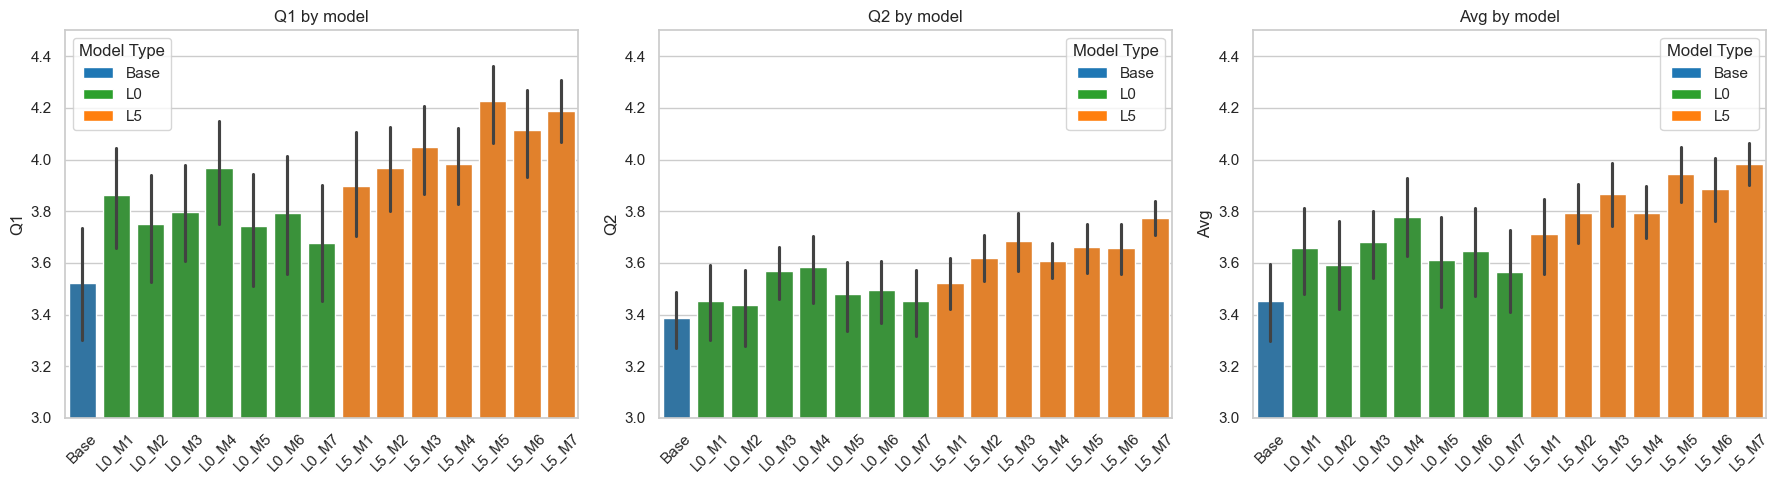

In [14]:
# Helper: barplot of a score metric by model
def barplot_metric(df, metric, ax=None):
    ax = ax or plt.gca()
    
    # Create a color mapping for each model type
    colors = {
        'Base': '#1f77b4',  # blue
        'L0': '#2ca02c',    # green
        'L5': '#ff7f0e'     # orange
    }
    
    # Map each unique model to its type color
    def model_type(model):
        if model.startswith('Base'):
            return 'Base'
        elif model.startswith('L0'):
            return 'L0'
        elif model.startswith('L5'):
            return 'L5'
        else:
            return 'Other'
    
    model_types = {model: model_type(model) for model in df['Model'].unique()}
    palette = {model: colors.get(model_types[model], '#888888') for model in df['Model'].unique()}
    
    sns.barplot(data=df, x='Model', y=metric, ax=ax, palette=palette)
    ax.set_title(f'{metric} by model')
    ax.set_xlabel('')
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
    
    # Add a legend for model types
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, label=label) for label, color in colors.items()]
    ax.legend(handles=legend_elements, title='Model Type')
    ax.set_ylim(3, 4.5)
    
    return ax

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, ['Q1', 'Q2', 'Avg']):
    barplot_metric(sub_data, m, ax=ax)
plt.tight_layout()
plt.show()

## 7. Statistical significance testing

In [15]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# One‑way ANOVA for average score
groups = [group['Avg'].values for _, group in sub_data.groupby('Model')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA F={f_stat:.3f}, p={p_val:.4g}")

# Tukey HSD
tukey = pairwise_tukeyhsd(sub_data['Avg'], sub_data['Model'])
print(tukey)

ANOVA F=4.299, p=1.622e-07
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Base  L0_M1   0.2039 0.8006 -0.1431 0.5509  False
  Base  L0_M2   0.1394 0.9901 -0.2076 0.4864  False
  Base  L0_M3   0.2285 0.6378 -0.1185 0.5755  False
  Base  L0_M4   0.3235  0.099 -0.0235 0.6705  False
  Base  L0_M5   0.1577 0.9695 -0.1893 0.5047  False
  Base  L0_M6    0.191 0.8679  -0.156  0.538  False
  Base  L0_M7   0.1115  0.999 -0.2355 0.4585  False
  Base  L5_M1   0.2572 0.4282 -0.0898 0.6042  False
  Base  L5_M2   0.3404 0.0611 -0.0066 0.6874  False
  Base  L5_M3   0.4132 0.0049  0.0662 0.7602   True
  Base  L5_M4   0.3402 0.0615 -0.0068 0.6872  False
  Base  L5_M5   0.4893 0.0002  0.1423 0.8364   True
  Base  L5_M6   0.4313 0.0024  0.0842 0.7783   True
  Base  L5_M7   0.5292    0.0  0.1822 0.8762   True
 L0_M1  L0_M2  -0.0645    1.0 -0.4115 0.2825  False
 L0_M1  L0_M3   0.0246    1.0 -0.3224